# Week 2 Internship Task

# Baseline Regression Modeling

## Objective

The objective of this notebook is to build baseline regression models for predicting steel industry energy consumption. The workflow includes data preprocessing, feature encoding, model training, evaluation, cross-validation, and model selection.

In [50]:
#inport the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load the feature engineered csv 

In [51]:


df = pd.read_csv("steel_industry_feature_engineered.csv")
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,daytype,Power_factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,weekday,1.545117,0


find missing value

In [52]:
df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Month                                   0
daytype                                 0
Power_factor_Ratio                      1
High_Load                               0
dtype: int64

# Drop Leakage Columns

The original Date column and High_Load are removed before training because they may leak target information.

fill the missing value in power factor ration

In [53]:
df["Power_factor_Ratio"]=df["Power_factor_Ratio"].fillna(df["Power_factor_Ratio"].mean())

In [54]:
df.drop(
    columns=["date", "High_Load"],
    inplace=True
)

df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,daytype,Power_factor_Ratio
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,weekday,1.365934
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,weekday,1.497679
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,weekday,1.422880
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,weekday,1.468644
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,weekday,1.545117


# Encode Categorical Features

One-Hot Encoding is used because it preserves all categories without introducing ordinal relationships.

In [55]:
df = pd.get_dummies(
    df,
    columns=[
        "WeekStatus",
        "Day_of_week",
        "Load_Type",
        "daytype",
        "Month"
    ],
    
    drop_first=True,
     dtype=int

)
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_factor_Ratio,WeekStatus_Weekend,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,0,...,0,0,1,0,0,0,0,0,0,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,0,...,0,0,1,0,0,0,0,0,0,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,0,...,0,0,1,0,0,0,0,0,0,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,0,...,0,0,1,0,0,0,0,0,0,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,0,...,0,0,1,0,0,0,0,0,0,0


Target and feature

In [56]:

X = df.drop("Usage_kWh", axis=1)
y = df["Usage_kWh"]



Train test split

In [57]:
from sklearn.model_selection import train_test_split


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)           


before apply linear regresion model to use standardscaler for normalize value

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_factor_Ratio,WeekStatus_Weekend,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,0,...,0,0,1,0,0,0,0,0,0,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,0,...,0,0,1,0,0,0,0,0,0,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,0,...,0,0,1,0,0,0,0,0,0,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,0,...,0,0,1,0,0,0,0,0,0,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,0,...,0,0,1,0,0,0,0,0,0,0


Apply the linear regresion model behind the intution math use the slope equation

In [60]:
from sklearn.linear_model import LinearRegression

model_linear=LinearRegression()

In [61]:
model_linear.fit(X_train_scaled, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 7.57,-0.62,23.72,...,-0.23,-0.59,-0.74]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,27
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](29,)","[360.14,324.29,239.73,..., 4.78, 0. , 0. ]"


In [62]:
y_pred=model_linear.predict(X_test_scaled)
y_pred

array([  1.50025189,  67.23723451, 123.53412983, ..., 146.74250175,
         3.96670479,  41.05573971], shape=(7008,))

model Evaluation

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [64]:
l_mae=mean_absolute_error(y_test,y_pred)
l_mse=mean_squared_error(y_test,y_pred)
l_r2=r2_score(y_test,y_pred)
l_rmse=np.sqrt(l_mse)

In [65]:
l_mae

2.7433158437727037

In [66]:
l_mse

17.410514810617553

In [67]:
l_r2

0.9846835817053669

In [68]:
l_rmse

np.float64(4.172590899023957)

scatter plot

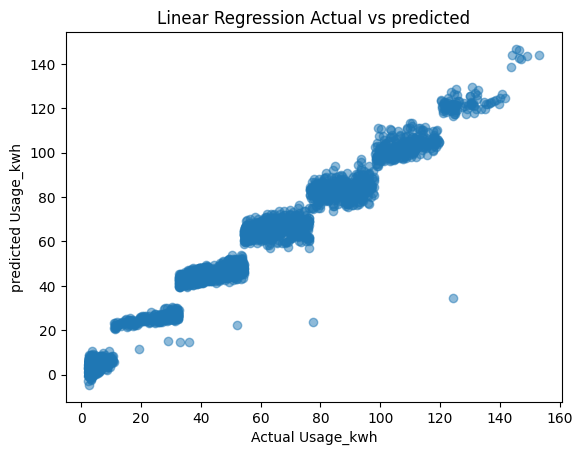

In [69]:
plt.Figure(figsize=(6,6))
plt.scatter(y_test,y_pred, alpha=0.5)
plt.xlabel("Actual Usage_kwh")
plt.ylabel("predicted Usage_kwh")
plt.title("Linear Regression Actual vs predicted")
plt.show()

#  Linear Regression 
In this section we trained a linear Regression model to predict electricty consumption(Usage_kwh)
the model was evaluated using:
maen absolute error(MAE)
mean squared error (mse)
r2 score 
finally we compared the actual and predicted values using a scatter plot.


# ridge Regression 
ridge regression is an extension of linear that applies l2 Regularization to reduce overfiting it adds a penalty term to the cost function shirking lare coefficient while retaining all feature 

In [70]:
from sklearn.linear_model import Ridge

In [71]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

prediction

In [72]:
ridge_pred = ridge.predict(X_test_scaled)

In [73]:
ridge_pred

array([  1.50946939,  67.2468099 , 123.53579557, ..., 146.73624698,
         3.96869883,  41.04593647], shape=(7008,))

find the mean sguare , mean absolute error and r2

In [74]:
ridge_mae=mean_absolute_error(y_test,ridge_pred)
ridge_mse=mean_squared_error(y_test,ridge_pred)
ridge_r2=r2_score(y_test,ridge_pred)
ridege_rmse=np.sqrt(ridge_mse)

In [75]:
ridge_mae

2.740292397168624

In [76]:
ridge_mse

17.404493657056296

In [77]:
ridge_r2

0.9846888786484821

In [78]:
ridege_rmse

np.float64(4.171869324062811)

visaualize the prediction use scatter plot

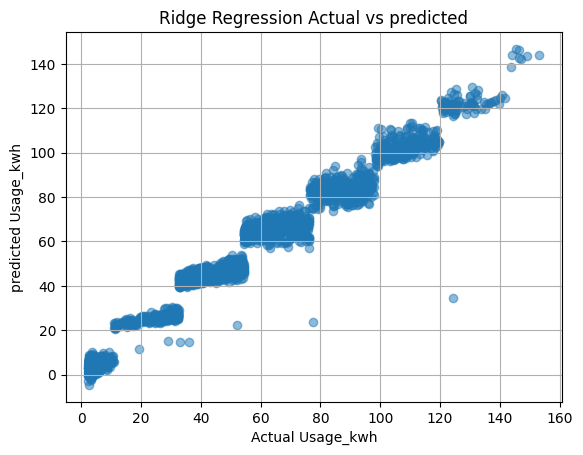

In [79]:
plt.Figure(figsize=(6,6))
plt.scatter(y_test,ridge_pred, alpha=0.5)
plt.xlabel("Actual Usage_kwh")
plt.ylabel("predicted Usage_kwh")
plt.title("Ridge Regression Actual vs predicted")
plt.grid(True)
plt.show()

# observation
the ridge model was evaluated using MAe , Mse and r2 score. Ridge regression rduces overfitting by adding an l2 regularization penalty making it more stable when feature are corelated 

# Decision tree regresor 
decision tree regressor is non_linear machine learing algorithm that predicts the target variable by recurisvely spliting the dataset based on the most informative feature it can capture complex relationship without requiring feature scaling

In [80]:
from sklearn.tree import DecisionTreeRegressor

In [81]:
model_dt=DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

prediction

In [82]:
dt_pred=model_dt.predict(X_test)
dt_pred

array([  2.88,  60.91, 123.98, ..., 146.48,   3.67,  38.09], shape=(7008,))

find the mean_squared , mean_absolute and r2

In [83]:
dt_mae=mean_absolute_error(y_test,dt_pred)
dt_mse=mean_squared_error(y_test,dt_pred)
dt_r2=r2_score(y_test,dt_pred)
dt_rmse=np.sqrt(dt_mse)

In [84]:
dt_mae

0.5410373858447489

In [85]:
dt_mse

2.3928904252283107

In [86]:
dt_r2

0.9978949209093078

In [87]:
dt_rmse

np.float64(1.5468970312300399)

visualize the result of Decision tree

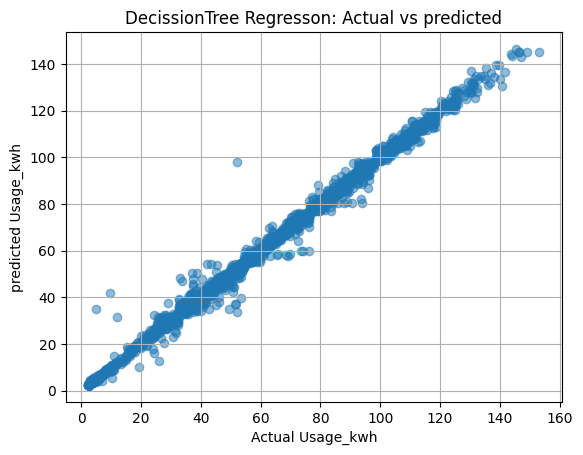

In [88]:
plt.Figure(figsize=(6,6))
plt.scatter(y_test,dt_pred, alpha=0.5)
plt.xlabel("Actual Usage_kwh")
plt.ylabel("predicted Usage_kwh")
plt.title("DecissionTree Regresson: Actual vs predicted")
plt.grid(True)
plt.show()

# Observation 
The Decision Tree Regrssor was evaluated using MAE, MSE and R2 score unlike linear models it learns non_linear patterns by splitting the data into decision nodes, it does not require feature scaling but may overfit it the tree to deep

# Rondom Forest regression 
Random forest regression is an ensemble learing algorthm that combines multiple Decision Trees to improve the prediction accuracy and overfiting 

In [89]:
from sklearn.ensemble import RandomForestRegressor

In [90]:
model_random=RandomForestRegressor(
    n_estimators=100, random_state=42
)
model_random.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

prediction

In [91]:
random_pred=model_random.predict(X_test)

Evaluation

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [93]:
rf_mae=mean_absolute_error(y_test, random_pred)
rf_mse=mean_squared_error(y_test, random_pred)
rf_r2=r2_score(y_test, random_pred)
rf_rmse=np.sqrt(rf_mse)

In [94]:
rf_mae

0.3459456621004556

In [95]:
rf_mse

1.0629733583390395

In [96]:
rf_r2

0.9990648786225182

In [97]:
rf_rmse

np.float64(1.0310059933574778)

## 5-Fold Cross Validation

5-Fold Cross Validation divides the dataset into five equal parts. The model is trained on four folds and tested on one fold. This process is repeated five times, and the average score is used to evaluate the model's performance.

5_fold cross validation for linear regression

In [99]:
from sklearn.model_selection import cross_val_score


In [101]:

model_linear = cross_val_score(
    model_linear,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

model_linear

array([0.9847388 , 0.98268306, 0.98239041, 0.98203906, 0.97449135])

In [102]:
model_linear.mean()

np.float64(0.9812685342883343)

5 fold validation for ridge

In [103]:

ridge = cross_val_score(
    ridge,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

ridge

array([0.9847454 , 0.98268469, 0.98239333, 0.98203771, 0.97448284])

In [104]:
ridge.mean()

np.float64(0.981268794974787)

5 fold validation for decission

In [105]:
dt_cv = cross_val_score(
    model_dt,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
dt_cv

array([0.99780207, 0.99740709, 0.99818633, 0.99786391, 0.99799955])

In [106]:
dt_cv.mean()

np.float64(0.9978517863416589)

5 fold validation for random forest

In [107]:
rf_cv = cross_val_score(
    model_random,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
rf_cv


array([0.9987307 , 0.99857101, 0.99908549, 0.99888234, 0.99893865])

In [108]:
rf_cv.mean()

np.float64(0.9988416383795521)